In [1]:
from pathlib import Path 
import os
os.environ['MUJOCO_GL'] = 'egl'
os.environ['MKL_SERVICE_FORCE_INTEL'] = '1'
from tqdm import tqdm
from IPython.display import Video

import torch
import numpy as np

import sys
sys.path.append("/srv/sferraro/choreographer/")

import envs
from envs.make import make

import matplotlib.pyplot as plt
import matplotlib.animation as animation

import mani_skill2
import mani_skill2.envs


[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /home/elephant/miniconda3/envs/urlb/lib/python3.8/site-packages/robosuite-1.4.0-py3.8.egg/robosuite/scripts/setup_macros.py (__init__.py:9)


In [61]:
# Import agent model (WM + Actor Critic)
agent_path = Path(f'/srv/sferraro/choreographer/notebooks/paper_visualizations/models/cube/dreamer_obj/snapshot_2000000.pt')

def load_agent(agent_path):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    with agent_path.open('rb') as f:
        obj = torch.load(f, map_location=torch.device(device))
        agent = obj['agent']    
        step = obj['_global_step']
        agent.device = device
        agent.wm.device = device
        agent.wm.rssm.device = device
        agent.wm.rssm._cell.device = device
    return agent, step

FOCUS_agent, global_step = load_agent(agent_path)

In [62]:
# Import agent model (WM + Actor Critic)
dreamer_agent_path = Path(f'/srv/sferraro/choreographer/notebooks/paper_visualizations/models/cube/dreamer/snapshot_2000000.pt')

dreamer_agent, global_step = load_agent(dreamer_agent_path)

In [4]:
from hydra import compose, initialize
from omegaconf import OmegaConf

initialize(config_path="../../exp_local/2023.05.20/122404_dreamer_obj_msPanda_CustomLiftYCB_/.hydra", job_name="config")
cfg = compose(config_name="config")

In [66]:
obs_type = dreamer_agent.cfg.obs_type
action_repeat = dreamer_agent.cfg.action_repeat
snapshot_ts = global_step * action_repeat

dreamer_agent.reward_free = True
FOCUS_agent.reward_free = True
dreamer_agent.use_selector = False
FOCUS_agent.use_selector = False
dreamer_agent.detached_exploration = True
FOCUS_agent.detached_exploration = True

seed = dreamer_agent.cfg.seed

seed = dreamer_agent.cfg.seed

task = "rsPanda_CustomLift"
domain = task.split("_")[0]

cfg.env.objects.minsize = 0.025
cfg.env.controller = "OSC_POSE"
cfg.env.renderer.camera = "agentview2"
cfg.env.objects.spawn_range = 0.0001

# Env creation
env = make(task, obs_type, frame_stack=1, 
                    action_repeat=action_repeat, seed=seed, env_config=cfg.env)

  0%|          | 0/3 [00:00<?, ?it/s]WARNING:matplotlib.image:Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


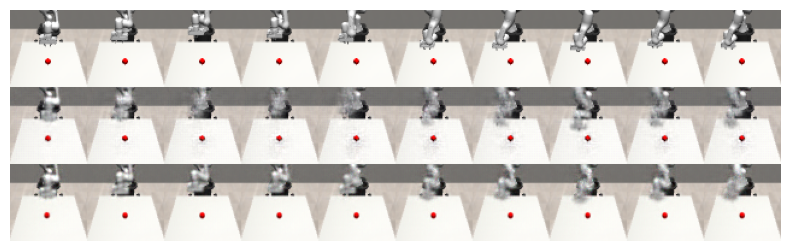

 33%|███▎      | 1/3 [00:03<00:07,  3.81s/it]WARNING:matplotlib.image:Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


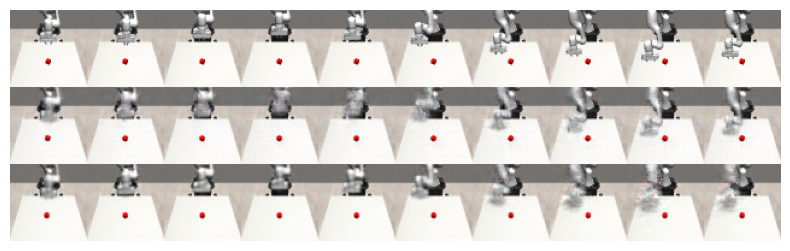

 67%|██████▋   | 2/3 [00:07<00:03,  3.79s/it]WARNING:matplotlib.image:Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


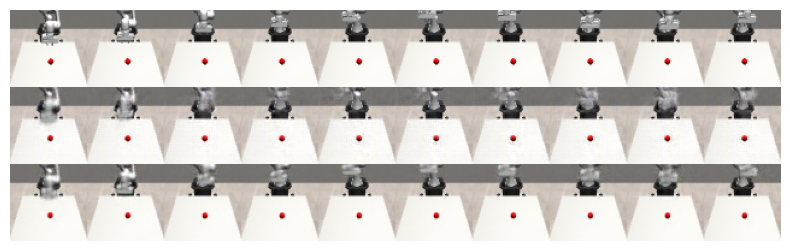

100%|██████████| 3/3 [00:11<00:00,  3.78s/it]


In [68]:

# get first observation from env (reset), feed it to encoder and get feat, feed features to actor for planning sequence, swap features to test out different objects
import utils
%matplotlib inline
from IPython import display
import imageio
from copy import deepcopy

newpath = r'./temp' 
if not os.path.exists(newpath):
    os.makedirs(newpath)

render_size = 64
camera = "agentview2"

eval_mode = True

agent_state = None
dreamer_meta = dreamer_agent.init_meta()
FOCUS_meta = FOCUS_agent.init_meta()

obs = env.reset()
episodes = 3

step, episode, total_reward = 0, 0, 0

instances = 2

# dreamer_agent._task_behavior.actor = lambda x : torch.rand(dreamer_agent.act_dim)
# FOCUS_agent._task_behavior.actor = lambda x : torch.rand(FOCUS_agent.act_dim)
# FOCUS_agent._expl_behavior.actor = lambda x : torch.rand(FOCUS_agent.act_dim)
        
for ep in tqdm(range(episodes)):
    dreamer_state, FOCUS_state = None, None
    obs = env.reset()
    step, total_reward = 0, 0
    
    f, ax = plt.subplots(1, figsize=(15, 3))
    ax.axis('off')
    
    # f, axs = plt.subplots(3, 12, figsize=(15, 3))
    # for i in range(3):
    #     for j in range(12):
    #         axs[i, j].axis('off')
            
    with torch.no_grad(), utils.eval_mode(dreamer_agent), utils.eval_mode(FOCUS_agent):
        while not bool(obs['is_last']):

            _, dreamer_state = dreamer_agent.act(
                                    obs,
                                    dreamer_meta,
                                    step,
                                    eval_mode=False,
                                    state=dreamer_state,
                                )
            
            _, FOCUS_state = FOCUS_agent.act(
                                    obs,
                                    FOCUS_meta,
                                    step,
                                    eval_mode=False,
                                    state=FOCUS_state,
                                )
            
            action = np.random.uniform(-1, 1, size=(dreamer_agent.act_dim)).astype(np.float32)
            
            dreamer_state = (dreamer_state[0], torch.tensor(action).to(dreamer_agent.device).unsqueeze(0)) 
            FOCUS_state = (FOCUS_state[0], torch.tensor(action).to(dreamer_agent.device).unsqueeze(0)) 
            
            obs = env.step(action)
            
            d_feat = dreamer_agent.wm.rssm.get_feat(dreamer_state[0]).unsqueeze(0)
            f_feat = FOCUS_agent.wm.rssm.get_feat(FOCUS_state[0]).unsqueeze(0)

            seg = torch.tensor(deepcopy(obs["segmentation"])).unsqueeze(0).unsqueeze(0).to(FOCUS_agent.device)
            rgb = torch.tensor(deepcopy(obs["rgb"])).to(FOCUS_agent.device) / 255.0
            
            f_prediction = FOCUS_agent.wm.heads["object_decoder"](f_feat, seg * 1.0)
            d_prediction = dreamer_agent.wm.heads["decoder"](d_feat)
            
            f_obs = f_prediction["rgb"].mean[0,0] + 0.5

            d_obs = d_prediction["rgb"].mean[0,0] + 0.5
            
            predicted_segmap = f_prediction["segmentation"].mean[0,0]
            
            # asssemble full predicted image
            f_out = torch.zeros((render_size, render_size, 3), device=dreamer_agent.device)
            for instance in range(instances):
                pred_seg_channel = predicted_segmap.permute(2, 0, 1)[instance].unsqueeze(-1)
                f_out = f_out + f_obs[instance].permute(1, 2, 0) * pred_seg_channel.repeat(1,1,3)
                
            
            if step % 13 == 0:
                if step == 0:
                    out = torch.cat((rgb, f_out.permute(2,0,1), d_obs), 1)
                else:
                    out = torch.cat((out, torch.cat((rgb, f_out.permute(2,0,1), d_obs), 1)), 2)

            step += 1
        
        ax.imshow(out.permute(1,2,0).cpu().numpy())
        
        plt.savefig(f'./images/{task}_{episode}.png', transparent = False, facecolor="white", bbox_inches='tight')
        plt.show()
        
    
    episode += 1
    
    frames = []
    
    # for t in range(step):
    #     image = imageio.v2.imread(f'./temp/img_{t}.png')
    #     frames.append(image)
        
    # imageio.mimsave('./out.gif', # output gif
    #             frames,          # array of input frames
    #             fps = 20)  
